In [ ]:
from pathlib import Path
import sys
import math
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from kaggle.api.kaggle_api_extended import KaggleApi


def _find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise RuntimeError("Could not find project root")


ROOT = _find_project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src import project_paths

%config InlineBackend.figure_format = 'retina'

In [26]:
# Authenticate
api = KaggleApi()
api.authenticate()

# Download dataset
api.dataset_download_files(
    "adityakadiwal/water-potability", path=project_paths.RAW_DATA_DIR, unzip=True
)

Dataset URL: https://www.kaggle.com/datasets/adityakadiwal/water-potability


In [27]:
df = pd.read_csv(project_paths.RAW_DATA_DIR / "water_potability.csv")
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [29]:
df.isna().sum()

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

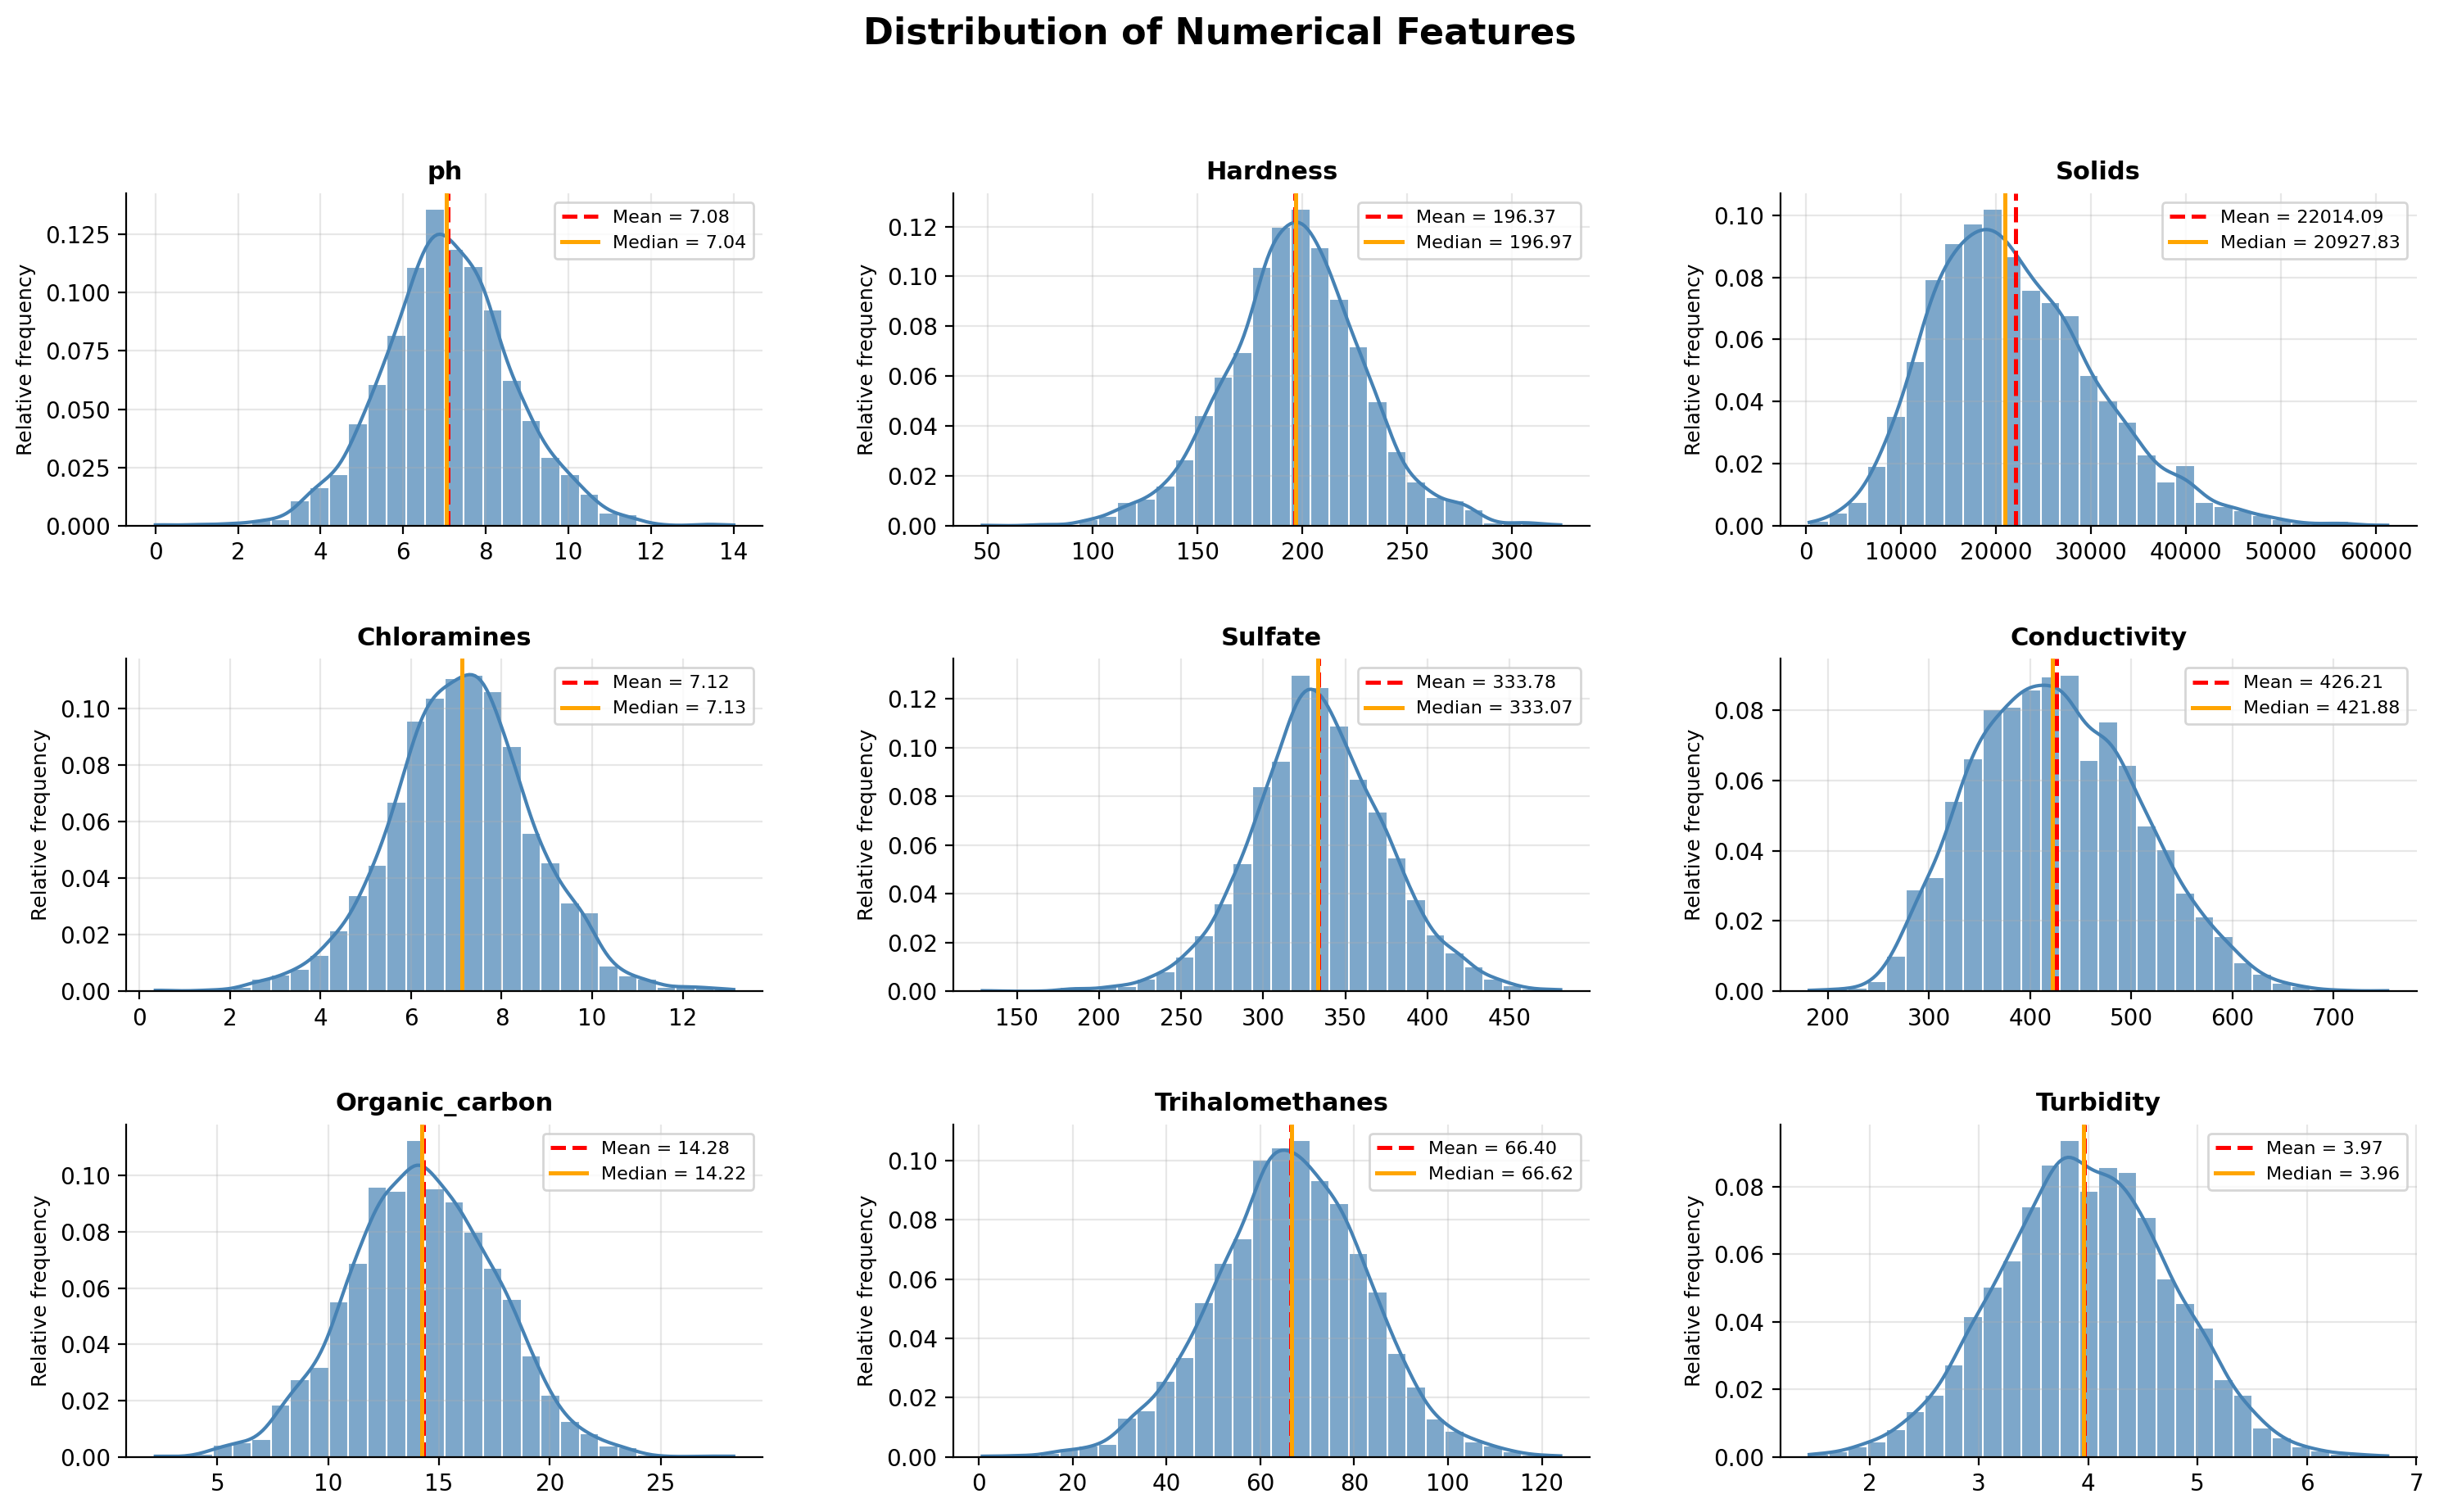

Skewness:
Solids             0.621634
Conductivity       0.264490
ph                 0.025630
Organic_carbon     0.025533
Turbidity         -0.007817
Chloramines       -0.012098
Sulfate           -0.035947
Hardness          -0.039342
Trihalomethanes   -0.083031
dtype: float64


In [30]:
cols = [col for col in df.columns.tolist() if col != "Potability"]

n_cols = 3
n_rows = math.ceil(len(cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3))

axes = axes.flatten() if len(cols) > 1 else [axes]

for i, col in enumerate(cols):
    mean = df[col].mean()
    median = df[col].median()

    sns.histplot(
        data=df,
        x=col,
        ax=axes[i],
        bins=30,
        kde=True,
        stat="probability",
        color="steelblue",
        alpha=0.7,
        edgecolor="white",
    )

    axes[i].axvline(
        mean, color="red", linestyle="--", linewidth=1.8, label=f"Mean = {mean:.2f}"
    )

    axes[i].axvline(
        median,
        color="orange",
        linestyle="-",
        linewidth=1.8,
        label=f"Median = {median:.2f}",
    )

    axes[i].set_title(col, fontsize=11, fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Relative frequency", fontsize=9)
    axes[i].grid(alpha=0.3)
    axes[i].legend(fontsize=8)

# Remove empty subplots
for j in range(len(cols), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(
    "Distribution of Numerical Features", fontsize=16, fontweight="bold", y=1.02
)

plt.tight_layout()
plt.subplots_adjust(top=0.9, hspace=0.4, wspace=0.3)
sns.despine()
plt.show()

# Skewness summary
print("Skewness:")
print(df[cols].skew().sort_values(ascending=False))

In [31]:
df.isna().sum()

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

In [41]:
from scipy.stats import zscore
import numpy as np
import pandas as pd

# Compute absolute Z-scores
z_scores = np.abs(zscore(df[cols]))

# Detect outliers using threshold |z| > 3
outliers = z_scores > 3

# Count outliers per feature
outlier_counts = outliers.sum(axis=0)

# Print feature -> number of outliers
print("Number of outliers detect:")
for col, count in zip(cols, outlier_counts):
    print(f"{col}: {count} outliers")


Number of outliers detect:
ph: 0 outliers
Hardness: 18 outliers
Solids: 20 outliers
Chloramines: 20 outliers
Sulfate: 0 outliers
Conductivity: 7 outliers
Organic_carbon: 4 outliers
Trihalomethanes: 0 outliers
Turbidity: 9 outliers


Given that the numerical features approximately follow Gaussian distributions, this characteristic will be taken into consideration during preprocessing, particularly for outlier detection, missing value imputation, and feature scaling.
